# ECON 5140: Applied Econometrics
## Lesson 10: Regression Discontinuity & Instrumental Variables

This notebook demonstrates **IV** and **RD** methods for causal inference when treatment is endogenous (unobserved confounding).

**Part 1 — Instrumental Variables (IV):**
1. Wald estimator (binary Z, binary D)
2. Two-Stage Least Squares (2SLS)
3. First-stage relevance and weak instruments

**Part 2 — Regression Discontinuity (RD):**
1. Sharp RD (treatment jumps at cutoff)
2. Fuzzy RD (eligibility ≠ compliance)
3. Local linear regression
4. RD diagnostics (McCrary density test, covariate balance)

We use simulated data with known true effects to illustrate identification.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---
# Part 1: Instrumental Variables (IV)
---

**Setup:** Education (D) affects earnings (Y), but ability (U) is unobserved and affects both. OLS is biased.

**Instrument:** Distance to college (Z) — affects education but not earnings directly.

**True LATE:** Effect of education on earnings for compliers = 8

## 1.1 Simulated IV Data

- **Z**: Binary instrument (1 = close to college, 0 = far)
- **U**: Unobserved ability (affects both D and Y)
- **D**: Education (1 = college, 0 = no college) — endogenous
- **Y**: Earnings — outcome

In [2]:
# IV data: Education and earnings with unobserved ability
np.random.seed(42)
n = 2000

# Instrument: random assignment (e.g., distance to college)
Z = np.random.binomial(1, 0.5, n)

# Unobserved ability (confounder)
U = np.random.normal(0, 1, n)

# Treatment D: education (affected by Z and U)
# Z increases prob of college; U (ability) also increases it
prob_D = 0.2 + 0.35 * Z + 0.25 * U  # Z and U both affect D
prob_D = np.clip(prob_D, 0.05, 0.95)
D = (np.random.uniform(0, 1, n) < prob_D).astype(int)

# Outcome Y: earnings (affected by D and U, NOT directly by Z)
# True LATE for compliers = 8
TRUE_LATE = 8.0
Y = 50 + TRUE_LATE * D + 15 * U + np.random.normal(0, 5, n)

df_iv = pd.DataFrame({'Z': Z, 'D': D, 'Y': Y})

print("IV Data Summary:")
print(f"  n = {n}")
print(f"  Z=1: {Z.sum()}, Z=0: {n-Z.sum()}")
print(f"  D=1 (college): {D.sum()}, D=0: {n-D.sum()}")
print(f"  True LATE = {TRUE_LATE}")

IV Data Summary:
  n = 2000
  Z=1: 1013, Z=0: 987
  D=1 (college): 785, D=0: 1215
  True LATE = 8.0


## 1.2 Naive OLS (Biased)

Regressing Y on D ignores unobserved ability U. OLS is biased because Cov(D,U) ≠ 0.

In [3]:
X_ols = sm.add_constant(df_iv['D'])
ols = OLS(df_iv['Y'], X_ols).fit()
print("Naive OLS: Y ~ D")
print(ols.summary2().tables[1])
print(f"\nOLS coefficient on D: {ols.params['D']:.3f} (biased; true LATE = {TRUE_LATE})")

Naive OLS: Y ~ D
           Coef.  Std.Err.           t          P>|t|     [0.025     0.975]
const  44.750255  0.415982  107.577423   0.000000e+00  43.934451  45.566059
D      21.181039  0.663979   31.900149  7.669798e-181  19.878874  22.483203

OLS coefficient on D: 21.181 (biased; true LATE = 8.0)


## 1.3 Wald Estimator

Wald = (E[Y|Z=1] - E[Y|Z=0]) / (E[D|Z=1] - E[D|Z=0])

- **Numerator**: Reduced form (effect of Z on Y)
- **Denominator**: First stage (effect of Z on D)

In [4]:
# First stage: E[D|Z=1] - E[D|Z=0]
first_stage = df_iv.groupby('Z')['D'].mean().diff().iloc[-1]

# Reduced form: E[Y|Z=1] - E[Y|Z=0]
reduced_form = df_iv.groupby('Z')['Y'].mean().diff().iloc[-1]

# Wald estimator
wald = reduced_form / first_stage

print("Wald Estimator Components:")
print(f"  First stage (Z→D):  E[D|Z=1] - E[D|Z=0] = {first_stage:.4f}")
print(f"  Reduced form (Z→Y): E[Y|Z=1] - E[Y|Z=0] = {reduced_form:.4f}")
print(f"  Wald = Reduced form / First stage = {wald:.4f}")
print(f"\n  True LATE = {TRUE_LATE}")

Wald Estimator Components:
  First stage (Z→D):  E[D|Z=1] - E[D|Z=0] = 0.3048
  Reduced form (Z→Y): E[Y|Z=1] - E[Y|Z=0] = 2.7741
  Wald = Reduced form / First stage = 9.1001

  True LATE = 8.0


## 1.4 Two-Stage Least Squares (2SLS)

**First stage:** Regress D on Z → get D_hat
**Second stage:** Regress Y on D_hat

2SLS uses only the variation in D explained by Z, isolating exogenous variation.

In [5]:
# First stage: D ~ Z
Z_const = sm.add_constant(df_iv['Z'])
fs = OLS(df_iv['D'], Z_const).fit()
D_hat = fs.predict(Z_const)

# Second stage: Y ~ D_hat
D_hat_const = sm.add_constant(D_hat)
ss = OLS(df_iv['Y'], D_hat_const).fit()

# First-stage F-statistic (rule of thumb: F < 10 → weak instrument)
f_stat = fs.fvalue

print("First Stage: D ~ Z")
print(fs.summary2().tables[1])
print(f"\nFirst-stage F-statistic: {f_stat:.2f} (rule of thumb: F >= 10 for strong instrument)")
print("\nSecond Stage: Y ~ D_hat")
print(ss.summary2().tables[1])
print(f"\n2SLS coefficient (LATE): {ss.params.iloc[1]:.4f}")

First Stage: D ~ Z
          Coef.  Std.Err.          t         P>|t|    [0.025    0.975]
const  0.238095  0.014774  16.115951  4.980196e-55  0.209121  0.267069
Z      0.304847  0.020759  14.685076  1.932122e-46  0.264135  0.345558

First-stage F-statistic: 215.65 (rule of thumb: F >= 10 for strong instrument)

Second Stage: Y ~ D_hat
           Coef.  Std.Err.          t          P>|t|     [0.025     0.975]
const  49.492019  1.097079  45.112526  4.540850e-307  47.340480  51.643559
0       9.100110  2.605564   3.492568   4.888029e-04   3.990202  14.210018

2SLS coefficient (LATE): 9.1001


## 1.5 Weak Instrument Demonstration

When Z barely affects D, the first stage is weak. IV estimates become unstable and biased toward OLS.

In [8]:
# Weak instrument: Z has very small effect on D
np.random.seed(123)
prob_D_weak = 0.4 + 0.02 * Z + 0.3 * U  # Z effect = 0.02 (very weak)
prob_D_weak = np.clip(prob_D_weak, 0.1, 0.9)
D_weak = (np.random.uniform(0, 1, n) < prob_D_weak).astype(int)
Y_weak = 50 + TRUE_LATE * D_weak + 15 * U + np.random.normal(0, 5, n)

# 2SLS with weak instrument
fs_weak = OLS(D_weak, Z_const).fit()
D_hat_weak = fs_weak.predict(Z_const)
ss_weak = OLS(Y_weak, sm.add_constant(D_hat_weak)).fit()

# OLS for comparison
ols_weak = OLS(Y_weak, sm.add_constant(D_weak)).fit()

print("Weak Instrument (Z has tiny effect on D):")
print(f"  First-stage F-statistic: {fs_weak.fvalue:.2f} (<< 10 → weak!)")
print(f"  First-stage coefficient: {fs_weak.params['Z']:.4f}")
print(f"\n  OLS coefficient:  {np.asarray(ols_weak.params)[-1]:.4f} (biased)")
print(f"  IV/2SLS coefficient: {np.asarray(ss_weak.params)[-1]:.4f} (unstable, biased toward OLS)")
print(f"  True LATE: {TRUE_LATE}")

Weak Instrument (Z has tiny effect on D):
  First-stage F-statistic: 0.82 (<< 10 → weak!)
  First-stage coefficient: 0.0200

  OLS coefficient:  22.5519 (biased)
  IV/2SLS coefficient: 29.4639 (unstable, biased toward OLS)
  True LATE: 8.0


---
# Part 2: Regression Discontinuity (RD)
---

**Setup:** Scholarship awarded if test score ≥ 80. We estimate the effect of scholarship on college enrollment.

**Sharp RD:** Treatment = 1{Running variable ≥ cutoff} (deterministic)

**Fuzzy RD:** Eligibility jumps at cutoff, but not everyone complies.

## 2.1 Simulated RD Data

- **X**: Running variable (test score, centered at cutoff 0)
- **D**: Treatment (scholarship)
- **Y**: Outcome (college enrollment)

In [9]:
# RD data: Scholarship eligibility at test score cutoff
np.random.seed(42)
n_rd = 2000
cutoff = 0  # X centered at cutoff

# Running variable: test score (centered at cutoff)
X = np.random.uniform(-30, 30, n_rd)

# Sharp RD: D = 1 if X >= cutoff
D_sharp = (X >= cutoff).astype(int)

# Outcome: Y depends on D and smooth function of X
# True treatment effect at cutoff = 0.35
TRUE_RD_EFFECT = 0.35
Y_sharp = 0.3 + 0.002 * X + TRUE_RD_EFFECT * D_sharp + np.random.normal(0, 0.1, n_rd)
Y_sharp = np.clip(Y_sharp, 0, 1)  # Enrollment rate in [0,1]

# Fuzzy RD: eligibility at cutoff, but imperfect compliance
eligible = (X >= cutoff).astype(int)
take_up = 0.3 + 0.5 * eligible + 0.1 * np.random.normal(0, 1, n_rd)
take_up = np.clip(take_up, 0, 1)
D_fuzzy = (np.random.uniform(0, 1, n_rd) < take_up).astype(int)
Y_fuzzy = 0.3 + 0.002 * X + TRUE_RD_EFFECT * D_fuzzy + np.random.normal(0, 0.1, n_rd)
Y_fuzzy = np.clip(Y_fuzzy, 0, 1)

df_rd = pd.DataFrame({'X': X, 'D_sharp': D_sharp, 'D_fuzzy': D_fuzzy, 'Y_sharp': Y_sharp, 'Y_fuzzy': Y_fuzzy})

print("RD Data Summary:")
print(f"  n = {n_rd}, Cutoff = {cutoff}")
print(f"  Below cutoff: {(X < cutoff).sum()}, Above cutoff: {(X >= cutoff).sum()}")
print(f"  True RD effect = {TRUE_RD_EFFECT}")

RD Data Summary:
  n = 2000, Cutoff = 0
  Below cutoff: 987, Above cutoff: 1013
  True RD effect = 0.35


## 2.2 Local Linear Regression (Sharp RD)

Fit separate linear regressions on each side of the cutoff. The **jump** at the cutoff = treatment effect.

## 2.5 Fuzzy RD: Imperfect Compliance

In **fuzzy RD**, treatment is not perfectly determined by the cutoff. **Below** the cutoff the proportion treated is < 1 (some get treatment despite ineligibility). **Above** the cutoff the proportion treated is > 0 but < 1 (some don't take up despite eligibility). The plot shows this imperfect compliance.

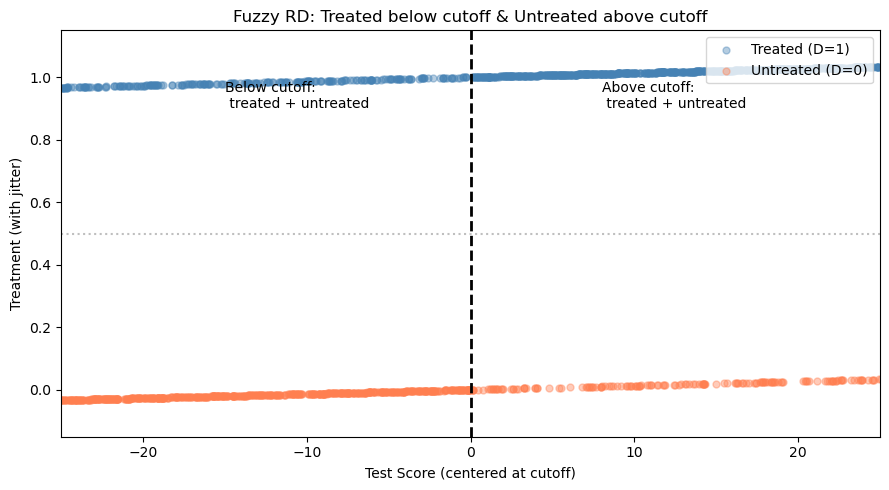

In [16]:
# First stage: Proportion treated by bin (shows imperfect compliance)
bins = np.arange(-30, 31, 5)
df_rd['bin'] = pd.cut(df_rd['X'], bins=bins)
binned = df_rd.groupby('bin').agg({'X': 'mean', 'D_fuzzy': 'mean'}).reset_index()
binned = binned.dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(binned['X'], binned['D_fuzzy'], s=80, alpha=0.8, c='steelblue', edgecolors='black')
ax.axvline(cutoff, color='black', linestyle='--', lw=2)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axhline(1, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Test Score (centered at cutoff)')
ax.set_ylabel('Proportion Treated')
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-25, 25)
ax.set_title('Fuzzy RD: Below cutoff some treated; above cutoff some untreated')
ax.annotate('Below: prop < 1\n(some untreated)', xy=(-18, 0.25), fontsize=10)
ax.annotate('Above: prop > 0\n(some untreated)', xy=(5, 0.85), fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
def local_linear_rd(X, Y, cutoff, bandwidth):
    """Estimate RD effect using local linear regression."""
    mask = np.abs(X - cutoff) <= bandwidth
    X_m = X[mask]
    Y_m = Y[mask]
    
    left = X_m < cutoff
    right = X_m >= cutoff
    
    # Left of cutoff
    X_left = sm.add_constant(X_m[left] - cutoff)
    m_left = OLS(Y_m[left], X_left).fit()
    
    # Right of cutoff
    X_right = sm.add_constant(X_m[right] - cutoff)
    m_right = OLS(Y_m[right], X_right).fit()
    
    # Jump at cutoff = intercept difference
    jump = m_right.params[0] - m_left.params[0]
    return jump, m_left, m_right, X_m, Y_m

bandwidth = 15
jump_sharp, m_left, m_right, X_m, Y_m = local_linear_rd(df_rd['X'], df_rd['Y_sharp'], cutoff, bandwidth)

print(f"Sharp RD (bandwidth = {bandwidth}):")
print(f"  Estimated discontinuity (jump) = {jump_sharp:.4f}")
print(f"  True effect = {TRUE_RD_EFFECT}")

Sharp RD (bandwidth = 15):
  Estimated discontinuity (jump) = 0.3306
  True effect = 0.35


## 2.3 RD Plot (Sharp RD)

Binned means and local linear fits. The vertical jump at the cutoff = treatment effect.

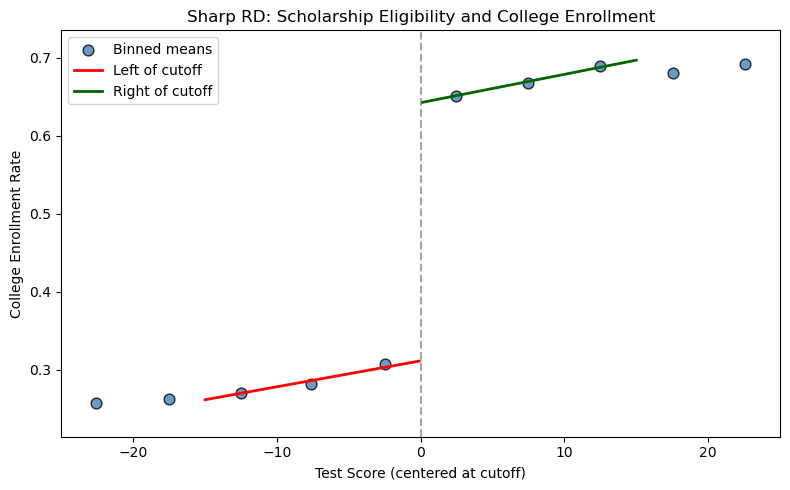

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

# Binned means
bins = np.arange(-30, 31, 5)
df_rd['bin'] = pd.cut(df_rd['X'], bins=bins)
binned = df_rd.groupby('bin').agg({'X': 'mean', 'Y_sharp': 'mean'}).dropna()
ax.scatter(binned['X'], binned['Y_sharp'], s=60, alpha=0.8, color='steelblue', edgecolors='black', label='Binned means')

# Local linear fits
x_left = np.linspace(-bandwidth, cutoff - 0.1, 50)
x_right = np.linspace(cutoff + 0.1, bandwidth, 50)
ax.plot(x_left, m_left.predict(sm.add_constant(x_left - cutoff)), 'r-', lw=2, label='Left of cutoff')
ax.plot(x_right, m_right.predict(sm.add_constant(x_right - cutoff)), 'darkgreen', lw=2, label='Right of cutoff')

ax.axvline(cutoff, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Test Score (centered at cutoff)')
ax.set_ylabel('College Enrollment Rate')
ax.set_title('Sharp RD: Scholarship Eligibility and College Enrollment')
ax.legend()
ax.set_xlim(-25, 25)
plt.tight_layout()
plt.show()

## 2.4 Fuzzy RD: Wald Estimator at the Cutoff

In fuzzy RD, treatment doesn't jump from 0 to 1. The estimand is:

**Effect = Jump in Y / Jump in D** (Wald at cutoff)

In [12]:
# Fuzzy RD: estimate jump in Y and jump in D
jump_Y, _, _, _, _ = local_linear_rd(df_rd['X'], df_rd['Y_fuzzy'], cutoff, bandwidth)
jump_D, _, _, _, _ = local_linear_rd(df_rd['X'], df_rd['D_fuzzy'], cutoff, bandwidth)

fuzzy_rd_effect = jump_Y / jump_D

print("Fuzzy RD (Wald at cutoff):")
print(f"  Jump in Y (outcome) = {jump_Y:.4f}")
print(f"  Jump in D (treatment) = {jump_D:.4f}")
print(f"  Fuzzy RD effect = Jump_Y / Jump_D = {fuzzy_rd_effect:.4f}")
print(f"  True effect = {TRUE_RD_EFFECT}")

Fuzzy RD (Wald at cutoff):
  Jump in Y (outcome) = 0.2129
  Jump in D (treatment) = 0.5585
  Fuzzy RD effect = Jump_Y / Jump_D = 0.3812
  True effect = 0.35


## 2.5 RD Diagnostics

**1. McCrary density test:** Is there a discontinuity in the density of X at the cutoff? (Suggests manipulation.)

**2. Covariate balance:** Pre-treatment covariates should be smooth at the cutoff.

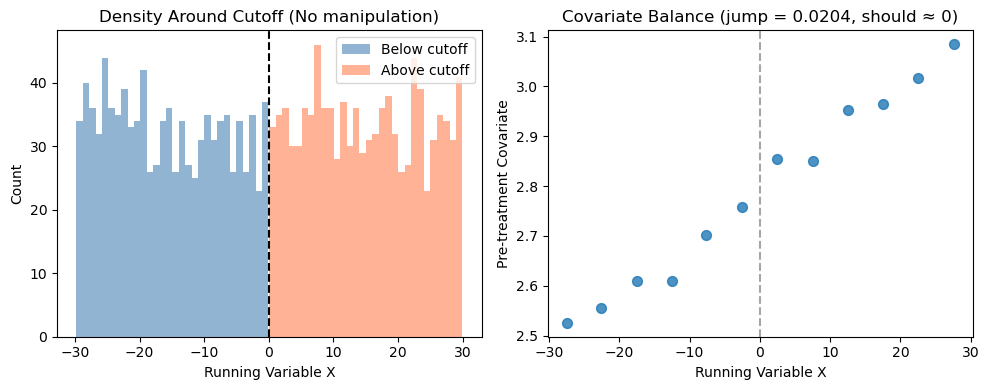

Covariate jump at cutoff: 0.0204 (small = good balance)


In [13]:
# Simulate a covariate (e.g., prior GPA) - should be smooth at cutoff
df_rd['covariate'] = 2.8 + 0.01 * df_rd['X'] + np.random.normal(0, 0.3, n_rd)
df_rd['covariate'] = np.clip(df_rd['covariate'], 1, 4)

# McCrary-style: compare density left vs right (simplified)
n_left = (df_rd['X'] < cutoff).sum()
n_right = (df_rd['X'] >= cutoff).sum()
bw = 5
in_band = (np.abs(df_rd['X'] - cutoff) <= bw)
density_left = (df_rd.loc[in_band & (df_rd['X'] < cutoff), 'X']).count() / (2 * bw)
density_right = (df_rd.loc[in_band & (df_rd['X'] >= cutoff), 'X']).count() / (2 * bw)

# Covariate continuity: jump in covariate at cutoff
jump_cov, _, _, _, _ = local_linear_rd(df_rd['X'], df_rd['covariate'], cutoff, bandwidth)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Density (histogram)
axes[0].hist(df_rd['X'][df_rd['X'] < cutoff], bins=30, alpha=0.6, label='Below cutoff', color='steelblue')
axes[0].hist(df_rd['X'][df_rd['X'] >= cutoff], bins=30, alpha=0.6, label='Above cutoff', color='coral')
axes[0].axvline(cutoff, color='black', linestyle='--')
axes[0].set_xlabel('Running Variable X')
axes[0].set_ylabel('Count')
axes[0].set_title('Density Around Cutoff (No manipulation)')
axes[0].legend()

# Covariate balance
binned_cov = df_rd.groupby('bin').agg({'X': 'mean', 'covariate': 'mean'}).dropna()
axes[1].scatter(binned_cov['X'], binned_cov['covariate'], s=50, alpha=0.8)
axes[1].axvline(cutoff, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Running Variable X')
axes[1].set_ylabel('Pre-treatment Covariate')
axes[1].set_title(f'Covariate Balance (jump = {jump_cov:.4f}, should ≈ 0)')
plt.tight_layout()
plt.show()

print(f"Covariate jump at cutoff: {jump_cov:.4f} (small = good balance)")

## Summary

| Method | Identifies | Key Assumption |
|--------|------------|----------------|
| IV (Wald/2SLS) | LATE (compliers) | Z relevant, independent, exclusion |
| Sharp RD | Effect at cutoff | Continuity of potential outcomes |
| Fuzzy RD | LATE at cutoff | Same + treatment jump at cutoff |

Both IV and RD isolate **exogenous variation** in treatment when confounders are unobserved.